# ResNet Classification: AI vs Real + Category

## Overview
This notebook solves two independent classification problems using ResNet-50:

| Problem | Type | Classes | Metric focus |
|---------|------|---------|-------------|
| **Problem 1** | Binary | AI vs Real | F1, AUC-ROC (imbalanced classes) |
| **Problem 2** | Multi-class | animals / city / food / nature / people | F1-macro, Confusion Matrix |

Each problem has a **champion-challenger pair**:

| Model | Architecture | Strategy |
|-------|-------------|----------|
| **Baseline** | Frozen ResNet-50 + single Linear layer | Only the final layer trains |
| **Champion** | Fully fine-tuned ResNet-50 + deep MLP head | All layers train, richer classifier |

## What is ResNet-50?
ResNet (Residual Network) was introduced by Microsoft Research in 2015 and won the ImageNet competition that year. The key innovation is **skip connections** (also called residual connections):

```
Normal layer:    output = F(input)
ResNet layer:    output = F(input) + input   ← adds the input directly
```

Adding the raw input back solves the **vanishing gradient problem** in very deep networks, gradients shrink to near-zero during backpropagation, making early layers stop learning. Skip connections give gradients a direct highway back through the network.

ResNet-50 has 50 layers and ~25 million parameters. It was pretrained on ImageNet (1.2M images, 1000 classes), so its features already encode rich visual understanding.

## What is the deep MLP head?
The baseline replaces ResNet's final layer with a single `Linear(2048 → num_classes)`.  
The champion replaces it with a **Multi-Layer Perceptron (MLP)**:
```
Linear(2048 → 512) → BatchNorm → ReLU → Dropout
Linear(512  → 256) → BatchNorm → ReLU → Dropout  
Linear(256  → num_classes)
```
More layers = the classifier can learn more complex decision boundaries from the features the backbone produces.

## 1. Setup & Imports

In [1]:
import os, random, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split
import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyperparameters ──
IMAGE_SIZE     = 224
BATCH_SIZE     = 32
NUM_WORKERS    = 0      
EPOCHS_BASE    = 5      
EPOCHS_CHAMP   = 15    
LR_BASE        = 1e-3    
LR_CHAMP       = 1e-4    
DROPOUT        = 0.4   

# ── Label mappings ──
BINARY_LABELS   = {'Real': 0, 'AI': 1}
CATEGORY_LABELS = {'animals': 0, 'city': 1, 'food': 2, 'nature': 3, 'people': 4}
IDX_TO_BINARY   = {v: k for k, v in BINARY_LABELS.items()}
IDX_TO_CATEGORY = {v: k for k, v in CATEGORY_LABELS.items()}
BINARY_NAMES    = ['Real', 'AI']
CATEGORY_NAMES  = ['animals', 'city', 'food', 'nature', 'people']

# ── Device ──
if torch.cuda.is_available():           DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available(): DEVICE = torch.device('mps')
else:                                   DEVICE = torch.device('cpu')

print(f'Setup complete')
print(f'   PyTorch : {torch.__version__}')
print(f'   Device  : {DEVICE}')

Setup complete
   PyTorch : 2.11.0
   Device  : mps


## 2. Load Data

In [2]:
def build_dataframe(dataset_path):
    IMAGE_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
    LABEL_MAP = {'real_dataset': 'Real', 'Ai_generated_dataset': 'AI'}
    records = []
    for label_folder in sorted(Path(dataset_path).iterdir()):
        if not label_folder.is_dir(): continue
        label = LABEL_MAP.get(label_folder.name, label_folder.name)
        for cat_folder in sorted(label_folder.iterdir()):
            if not cat_folder.is_dir(): continue
            for img_path in cat_folder.iterdir():
                if img_path.suffix.lower() in IMAGE_EXT:
                    records.append({
                        'path'        : str(img_path),
                        'label'       : label,
                        'label_idx'   : BINARY_LABELS[label],
                        'category'    : cat_folder.name,
                        'category_idx': CATEGORY_LABELS[cat_folder.name],
                    })
    return pd.DataFrame(records)

try:
    df_train = pd.read_csv("/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/train_split.csv")
    df_val   = pd.read_csv("/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/val_split.csv")
    df_test  = pd.read_csv("/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/test_split.csv")
    # ensure category_idx exists
    for d in [df_train, df_val, df_test]:
        if 'category_idx' not in d.columns:
            d['category_idx'] = d['category'].map(CATEGORY_LABELS)
        if 'label_idx' not in d.columns:
            d['label_idx'] = d['label'].map(BINARY_LABELS)
    print(' Loaded splits from CSV')
except FileNotFoundError:
    print('CSV not found — rebuilding from scratch...')
    raw_path = kagglehub.dataset_download('rhythmghai/ai-vs-real-images-dataset')
    df = build_dataframe(raw_path)
    df['strat_key'] = df['label'] + '_' + df['category']
    df_tv, df_test  = train_test_split(df, test_size=0.15, stratify=df['strat_key'], random_state=SEED)
    df_train, df_val = train_test_split(df_tv, test_size=0.15/0.85, stratify=df_tv['strat_key'], random_state=SEED)
    for d in [df_train, df_val, df_test]:
        d.reset_index(drop=True, inplace=True)

print(f'   Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'   Train class balance: {df_train["label"].value_counts().to_dict()}')

 Loaded splits from CSV
   Train: 695 | Val: 150 | Test: 150
   Train class balance: {'Real': 520, 'AI': 175}


## 3. Dataset & DataLoaders

In [ ]:
# Transforms
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class AIvsRealDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return (
            image,
            torch.tensor(int(row['label_idx']),    dtype=torch.long),
            torch.tensor(int(row['category_idx']), dtype=torch.long)
        )

    def get_binary_labels(self):
        return self.df['label_idx'].astype(int).tolist()

# Build datasets
train_ds = AIvsRealDataset(df_train, train_transforms)
val_ds   = AIvsRealDataset(df_val,   val_test_transforms)
test_ds  = AIvsRealDataset(df_test,  val_test_transforms)

# WeightedRandomSampler for binary imbalance
bin_labels    = train_ds.get_binary_labels()
class_counts  = Counter(bin_labels)
sample_weights = torch.tensor([1.0 / class_counts[l] for l in bin_labels])
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)

# Quick shape check
imgs, b_labels, c_labels = next(iter(train_loader))
print(f' DataLoaders ready')
print(f'   Image shape    : {imgs.shape}')       # [32, 3, 224, 224]
print(f'   Binary labels  : {b_labels[:6].tolist()}')
print(f'   Category labels: {c_labels[:6].tolist()}')

 DataLoaders ready
   Image shape    : torch.Size([32, 3, 224, 224])
   Binary labels  : [0, 0, 0, 1, 0, 1]
   Category labels: [3, 3, 2, 4, 3, 1]


## 4. Model Architectures

### ResNet-50 Architecture Overview

```
Input (224×224×3)
    ↓
Conv1 + BN + ReLU + MaxPool
    ↓
Layer1: 3× Residual blocks  (256 channels)
    ↓
Layer2: 4× Residual blocks  (512 channels)
    ↓
Layer3: 6× Residual blocks  (1024 channels)
    ↓
Layer4: 3× Residual blocks  (2048 channels)
    ↓
Global Average Pooling → 2048-dim feature vector
    ↓
Classifier Head  ← this is what we replace
```

### Baseline Head (simple)
```
Linear(2048 → num_classes)
```

### Champion Head (deep MLP)
```
Linear(2048 → 512) → BatchNorm1d → ReLU → Dropout(0.4)
Linear(512  → 256) → BatchNorm1d → ReLU → Dropout(0.4)
Linear(256  → num_classes)
```
**BatchNorm1d** normalizes the activations within each layer — stabilizes training and acts as a regularizer.  
**Dropout(0.4)** randomly zeroes 40% of neurons during training — prevents the head from memorizing.

In [ ]:
def build_baseline_resnet(num_classes):
    """
    Frozen ResNet-50 with a single linear classifier.
    Only the final layer trains — fast, strong starting point.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze ALL backbone parameters
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully-connected layer
    # ResNet-50's fc layer: Linear(2048 → 1000)
    in_features = model.fc.in_features  # = 2048
    model.fc = nn.Linear(in_features, num_classes)
    # New layer has requires_grad=True by default → will be trained

    return model.to(DEVICE)


def build_champion_resnet(num_classes):
    """
    Fully fine-tuned ResNet-50 with a deep MLP classifier head.
    All layers train. Richer head learns more complex decision boundaries.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # All parameters stay trainable (no freezing)
    in_features = model.fc.in_features  # = 2048

    # Replace with deep MLP head
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(DROPOUT),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(DROPOUT),
        nn.Linear(256, num_classes)
    )

    return model.to(DEVICE)


def count_params(model, name):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'{name}:')
    print(f'  Trainable : {trainable:>12,}  ({trainable/total*100:.1f}% of total)')
    print(f'  Frozen    : {total-trainable:>12,}')
    print(f'  Total     : {total:>12,}')

# Instantiate all four models
baseline_binary   = build_baseline_resnet(num_classes=2)
baseline_category = build_baseline_resnet(num_classes=5)
champion_binary   = build_champion_resnet(num_classes=2)
champion_category = build_champion_resnet(num_classes=5)

print(' Parameter Counts ')
count_params(baseline_binary,   'Baseline Binary   (frozen backbone + Linear)')
print()
count_params(champion_binary,   'Champion Binary   (full fine-tune + deep MLP)')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/bestek/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:06<00:00, 15.6MB/s]


=== Parameter Counts ===
Baseline Binary   (frozen backbone + Linear):
  Trainable :        4,098  (0.0% of total)
  Frozen    :   23,508,032
  Total     :   23,512,130

Champion Binary   (full fine-tune + deep MLP):
  Trainable :   24,690,498  (100.0% of total)
  Frozen    :            0
  Total     :   24,690,498

Category models have same architecture, just num_classes=5 instead of 2


## 5. Training Utilities

Shared functions used by all four models.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, task='binary'):
    """
    One full pass through the training data.
    task = 'binary'   → uses binary labels
    task = 'category' → uses category labels
    """
    model.train()  # enables dropout and batch norm training mode
    total_loss, correct, total = 0.0, 0, 0

    for imgs, b_labels, c_labels in loader:
        imgs     = imgs.to(device)
        labels   = b_labels.to(device) if task == 'binary' else c_labels.to(device)

        optimizer.zero_grad()       # clear gradients
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()             # compute gradients
        optimizer.step()            # update weights

        preds         = out.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total_loss   += loss.item() * imgs.size(0)
        total        += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, task='binary'):
    """
    Evaluate on val or test set.
    Returns loss, accuracy, predictions, probabilities, true labels.
    """
    model.eval()  # disables dropout, freezes batch norm
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_true = [], [], []

    for imgs, b_labels, c_labels in loader:
        imgs   = imgs.to(device)
        labels = b_labels.to(device) if task == 'binary' else c_labels.to(device)

        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(dim=1)

        correct    += (preds == labels).sum().item()
        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_true.extend(labels.cpu().tolist())
        # For binary: store P(AI); for category: store full probability vector
        if task == 'binary':
            all_probs.extend(probs[:, 1].cpu().tolist())
        else:
            all_probs.extend(probs.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_probs, all_true


def run_training(model, optimizer, scheduler, criterion, epochs, task, model_name):
    """Full training loop with val monitoring and best-weight saving."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights  = None

    print(f'Training {model_name} for {epochs} epochs...')
    print('-' * 65)

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, task)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE, task)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Save best weights
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            marker = ' ← best'
        else:
            marker = ''

        if scheduler: scheduler.step(vl_loss)

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
              f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} | '
              f'{time.time()-t0:.1f}s{marker}')

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f'\n✅ Restored best weights (val_loss={best_val_loss:.4f})')
    return history


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   's-', label='Val',   color='coral')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   's-', label='Val',   color='coral')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', bbox_inches='tight', dpi=150)
    plt.show()

✅ Training utilities defined


# PROBLEM 1: Binary Classification (AI vs Real)

## Pros and cons of ResNet-50 for this task

**Pros:**
- Skip connections allow very deep feature extraction without vanishing gradients
- ImageNet pretraining means it already detects textures, edges, and patterns relevant to real vs AI
- 2048-dim feature vector is rich enough to capture subtle AI generation artifacts
- Well understood and widely benchmarked results are interpretable

**Cons:**
- ~25M parameters risk of overfitting on only 695 training images
- Designed for object recognition, not forgery detection may miss frequency-domain artifacts
- Deeper than necessary for this task EfficientNet achieves similar performance with fewer parameters
- Batch normalization in backbone can be disrupted by the small dataset during fine-tuning

## 6a. Train Baseline (Binary)

Training Baseline Binary (Frozen ResNet-50 + Linear) for 5 epochs...
-----------------------------------------------------------------
Epoch  1/5 | Train Loss: 0.6064 Acc: 0.643 | Val Loss: 0.5454 Acc: 0.700 | 24.8s ← best
Epoch  2/5 | Train Loss: 0.3694 Acc: 0.860 | Val Loss: 0.2782 Acc: 0.940 | 22.4s ← best
Epoch  3/5 | Train Loss: 0.2736 Acc: 0.915 | Val Loss: 0.2034 Acc: 0.953 | 21.2s ← best
Epoch  4/5 | Train Loss: 0.2375 Acc: 0.918 | Val Loss: 0.1762 Acc: 0.940 | 21.6s ← best
Epoch  5/5 | Train Loss: 0.2135 Acc: 0.938 | Val Loss: 0.1759 Acc: 0.947 | 21.5s ← best

✅ Restored best weights (val_loss=0.1759)


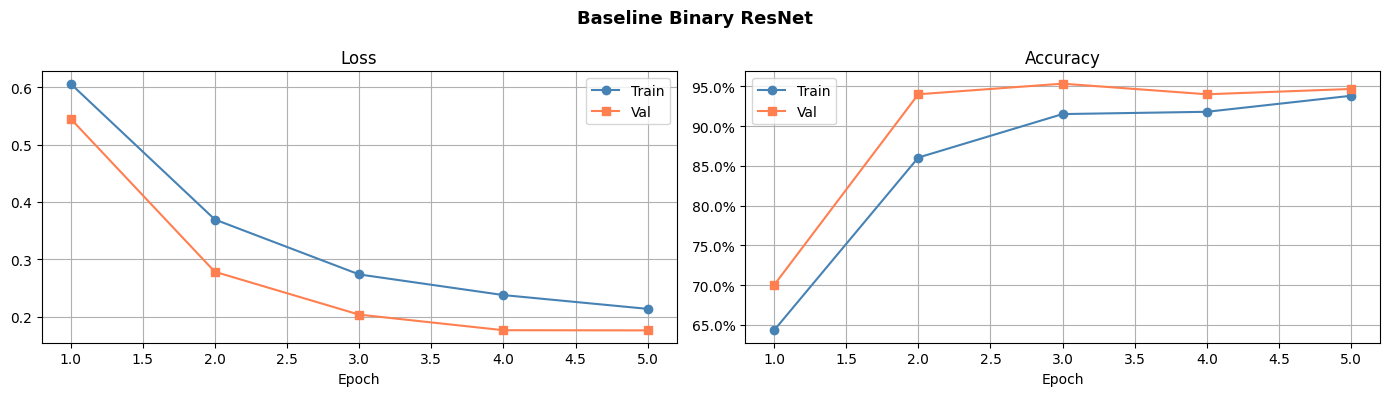

In [6]:
# Loss function — standard cross entropy, no class weights
# Imbalance is handled by WeightedRandomSampler in the data loader
criterion_binary = nn.CrossEntropyLoss()

# Only optimize trainable parameters (the new fc layer)
opt_base_bin = optim.Adam(
    filter(lambda p: p.requires_grad, baseline_binary.parameters()),
    lr=LR_BASE
)

history_base_bin = run_training(
    model      = baseline_binary,
    optimizer  = opt_base_bin,
    scheduler  = None,          # no scheduler for baseline
    criterion  = criterion_binary,
    epochs     = EPOCHS_BASE,
    task       = 'binary',
    model_name = 'Baseline Binary (Frozen ResNet-50 + Linear)'
)
plot_training_curves(history_base_bin, 'Baseline Binary ResNet')

## 6b. Train Champion (Binary)

Training Champion Binary (Fine-tuned ResNet-50 + Deep MLP) for 15 epochs...
-----------------------------------------------------------------
Epoch  1/15 | Train Loss: 0.3487 Acc: 0.875 | Val Loss: 0.3202 Acc: 0.913 | 45.5s ← best
Epoch  2/15 | Train Loss: 0.1137 Acc: 0.980 | Val Loss: 0.0885 Acc: 0.973 | 40.2s ← best
Epoch  3/15 | Train Loss: 0.0673 Acc: 0.990 | Val Loss: 0.0891 Acc: 0.973 | 39.0s
Epoch  4/15 | Train Loss: 0.0524 Acc: 0.987 | Val Loss: 0.1117 Acc: 0.933 | 39.9s
Epoch  5/15 | Train Loss: 0.0406 Acc: 0.993 | Val Loss: 0.0650 Acc: 0.980 | 39.9s ← best
Epoch  6/15 | Train Loss: 0.0335 Acc: 0.994 | Val Loss: 0.1033 Acc: 0.967 | 39.7s
Epoch  7/15 | Train Loss: 0.0267 Acc: 0.997 | Val Loss: 0.1111 Acc: 0.953 | 39.1s
Epoch  8/15 | Train Loss: 0.0223 Acc: 0.997 | Val Loss: 0.0764 Acc: 0.960 | 38.6s
Epoch  9/15 | Train Loss: 0.0133 Acc: 1.000 | Val Loss: 0.0686 Acc: 0.967 | 38.5s
Epoch 10/15 | Train Loss: 0.0146 Acc: 0.997 | Val Loss: 0.0609 Acc: 0.967 | 38.7s ← best
Epoch 11/1

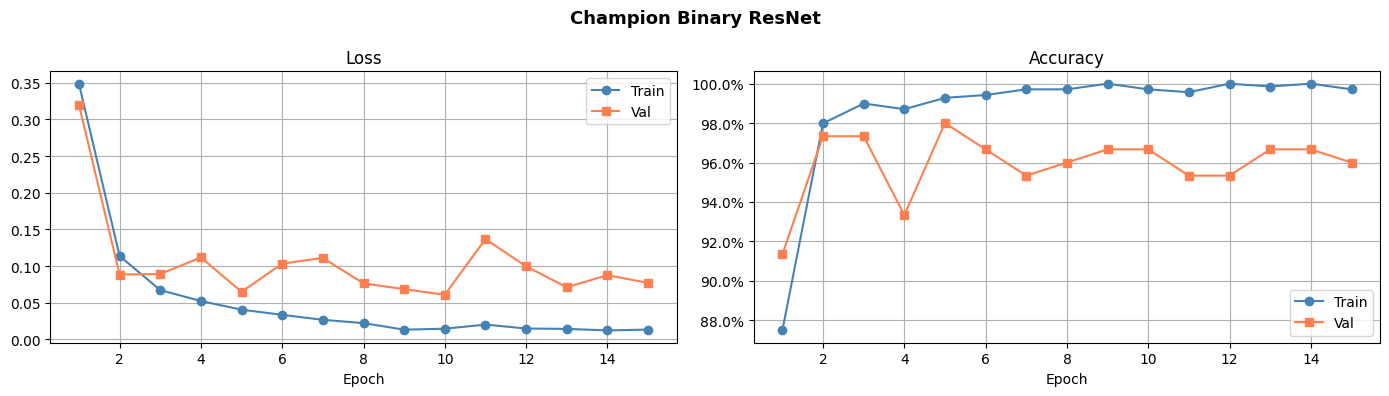

In [ ]:
# Lower LR for fine-tuning we're carefully updating pretrained weights
# weight_decay adds L2 regularization to prevent overfitting on small dataset
opt_champ_bin = optim.Adam(
    champion_binary.parameters(),
    lr=LR_CHAMP,
    weight_decay=1e-4
)

# Reduce LR by 50% if val loss doesn't improve for 3 epochs
scheduler_bin = optim.lr_scheduler.ReduceLROnPlateau(
    opt_champ_bin, mode='min', patience=3, factor=0.5
)

history_champ_bin = run_training(
    model      = champion_binary,
    optimizer  = opt_champ_bin,
    scheduler  = scheduler_bin,
    criterion  = criterion_binary,
    epochs     = EPOCHS_CHAMP,
    task       = 'binary',
    model_name = 'Champion Binary (Fine-tuned ResNet-50 + Deep MLP)'
)
plot_training_curves(history_champ_bin, 'Champion Binary ResNet')

# PROBLEM 2: Multi-Class Classification (5 Categories)

## Pros and cons of ResNet-50 for category classification

**Pros:**
- Category classification (animals vs city etc.) is closer to ImageNet's original task pretrained features transfer very well
- 5-class problem with 199 training images per class on average sufficient for fine-tuning
- Categories are visually very distinct even a shallow classifier on top of frozen features should perform well

**Cons:**
- With both AI and Real images in the same category, the model must learn category features that generalize across generation styles
- Nature vs Animals can be visually ambiguous (animals in natural settings)
- Same overfitting risk as binary task given the small dataset size

## 7a. Train Baseline  (Category)

Training Baseline Category (Frozen ResNet-50 + Linear) for 5 epochs...
-----------------------------------------------------------------
Epoch  1/5 | Train Loss: 0.3911 Acc: 0.918 | Val Loss: 0.2337 Acc: 0.940 | 23.7s ← best
Epoch  2/5 | Train Loss: 0.2041 Acc: 0.950 | Val Loss: 0.2048 Acc: 0.940 | 22.8s ← best
Epoch  3/5 | Train Loss: 0.1834 Acc: 0.951 | Val Loss: 0.1328 Acc: 0.967 | 21.7s ← best
Epoch  4/5 | Train Loss: 0.1539 Acc: 0.955 | Val Loss: 0.1489 Acc: 0.960 | 22.0s
Epoch  5/5 | Train Loss: 0.1307 Acc: 0.970 | Val Loss: 0.1333 Acc: 0.947 | 21.7s

✅ Restored best weights (val_loss=0.1328)


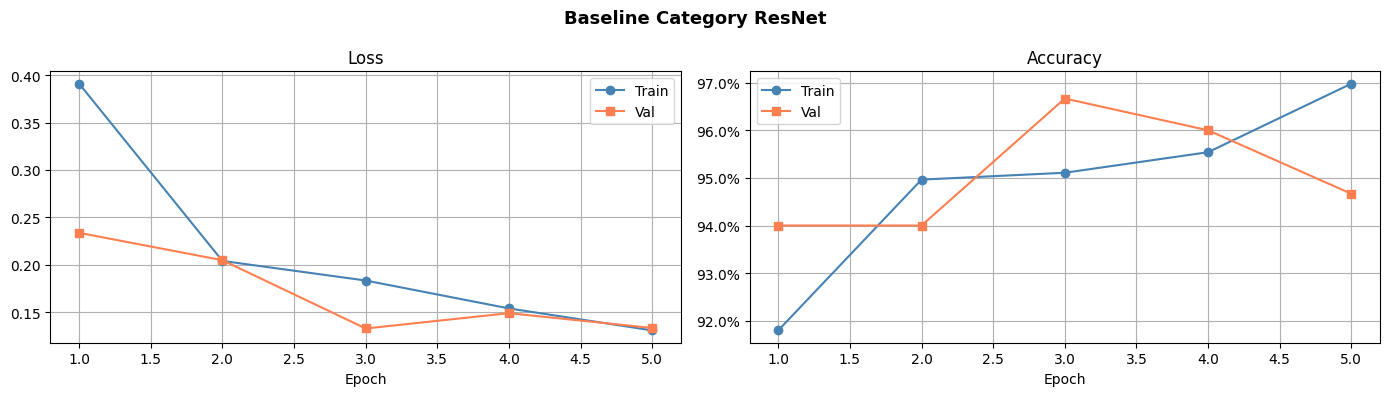

In [9]:
# Categories are balanced (~199 per class) — no class weighting needed
criterion_category = nn.CrossEntropyLoss()

opt_base_cat = optim.Adam(
    filter(lambda p: p.requires_grad, baseline_category.parameters()),
    lr=LR_BASE
)

history_base_cat = run_training(
    model      = baseline_category,
    optimizer  = opt_base_cat,
    scheduler  = None,
    criterion  = criterion_category,
    epochs     = EPOCHS_BASE,
    task       = 'category',
    model_name = 'Baseline Category (Frozen ResNet-50 + Linear)'
)
plot_training_curves(history_base_cat, 'Baseline Category ResNet')

## 7b. Train Champion (Category)

Training Champion Category (Fine-tuned ResNet-50 + Deep MLP) for 15 epochs...
-----------------------------------------------------------------
Epoch  1/15 | Train Loss: 0.9124 Acc: 0.722 | Val Loss: 0.5210 Acc: 0.953 | 39.8s ← best
Epoch  2/15 | Train Loss: 0.3265 Acc: 0.954 | Val Loss: 0.1912 Acc: 0.987 | 39.8s ← best
Epoch  3/15 | Train Loss: 0.1791 Acc: 0.984 | Val Loss: 0.1174 Acc: 0.987 | 38.2s ← best
Epoch  4/15 | Train Loss: 0.1595 Acc: 0.978 | Val Loss: 0.1611 Acc: 0.960 | 39.5s
Epoch  5/15 | Train Loss: 0.1189 Acc: 0.986 | Val Loss: 0.1145 Acc: 0.987 | 38.4s ← best
Epoch  6/15 | Train Loss: 0.1187 Acc: 0.983 | Val Loss: 0.1375 Acc: 0.953 | 39.3s
Epoch  7/15 | Train Loss: 0.1106 Acc: 0.987 | Val Loss: 0.1407 Acc: 0.960 | 39.3s
Epoch  8/15 | Train Loss: 0.0786 Acc: 0.996 | Val Loss: 0.1032 Acc: 0.973 | 39.1s ← best
Epoch  9/15 | Train Loss: 0.0607 Acc: 0.999 | Val Loss: 0.1231 Acc: 0.973 | 39.4s
Epoch 10/15 | Train Loss: 0.0610 Acc: 0.993 | Val Loss: 0.1373 Acc: 0.953 | 38.9s
E

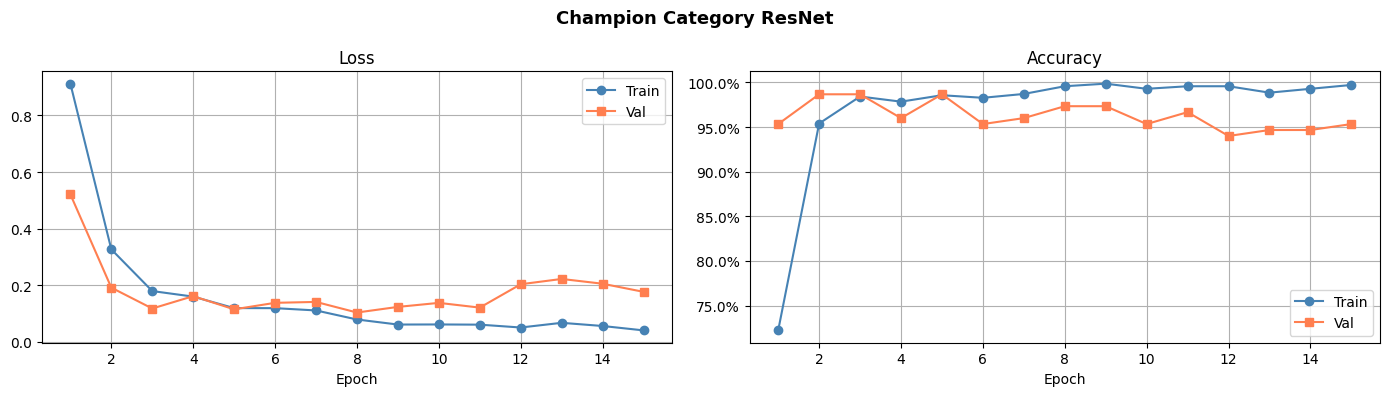

In [10]:
opt_champ_cat = optim.Adam(
    champion_category.parameters(),
    lr=LR_CHAMP,
    weight_decay=1e-4
)
scheduler_cat = optim.lr_scheduler.ReduceLROnPlateau(
    opt_champ_cat, mode='min', patience=3, factor=0.5
)

history_champ_cat = run_training(
    model      = champion_category,
    optimizer  = opt_champ_cat,
    scheduler  = scheduler_cat,
    criterion  = criterion_category,
    epochs     = EPOCHS_CHAMP,
    task       = 'category',
    model_name = 'Champion Category (Fine-tuned ResNet-50 + Deep MLP)'
)
plot_training_curves(history_champ_cat, 'Champion Category ResNet')

# Evaluation on Test Set
**We look at the test set exactly once here.**  
The test set was never used for training or any decisions during development.

## 8. Binary Classification Results

In [11]:
print('PROBLEM 1: BINARY CLASSIFICATION — AI vs Real')

# Evaluate both models
_, base_bin_acc, base_bin_preds, base_bin_probs, base_bin_true = evaluate(
    baseline_binary, test_loader, criterion_binary, DEVICE, 'binary')
_, champ_bin_acc, champ_bin_preds, champ_bin_probs, champ_bin_true = evaluate(
    champion_binary, test_loader, criterion_binary, DEVICE, 'binary')

print('\n BASELINE: Frozen ResNet-50 + Linear')
print(classification_report(base_bin_true, base_bin_preds,
      target_names=BINARY_NAMES, digits=4))
print(f'AUC-ROC: {roc_auc_score(base_bin_true, base_bin_probs):.4f}')

print('\n CHAMPION: Fine-tuned ResNet-50 + Deep MLP')
print(classification_report(champ_bin_true, champ_bin_preds,
      target_names=BINARY_NAMES, digits=4))
print(f'AUC-ROC: {roc_auc_score(champ_bin_true, champ_bin_probs):.4f}')

PROBLEM 1: BINARY CLASSIFICATION — AI vs Real

 BASELINE: Frozen ResNet-50 + Linear
              precision    recall  f1-score   support

        Real     0.9911    0.9823    0.9867       113
          AI     0.9474    0.9730    0.9600        37

    accuracy                         0.9800       150
   macro avg     0.9692    0.9776    0.9733       150
weighted avg     0.9803    0.9800    0.9801       150

AUC-ROC: 0.9976

 CHAMPION: Fine-tuned ResNet-50 + Deep MLP
              precision    recall  f1-score   support

        Real     0.9912    0.9912    0.9912       113
          AI     0.9730    0.9730    0.9730        37

    accuracy                         0.9867       150
   macro avg     0.9821    0.9821    0.9821       150
weighted avg     0.9867    0.9867    0.9867       150

AUC-ROC: 0.9998


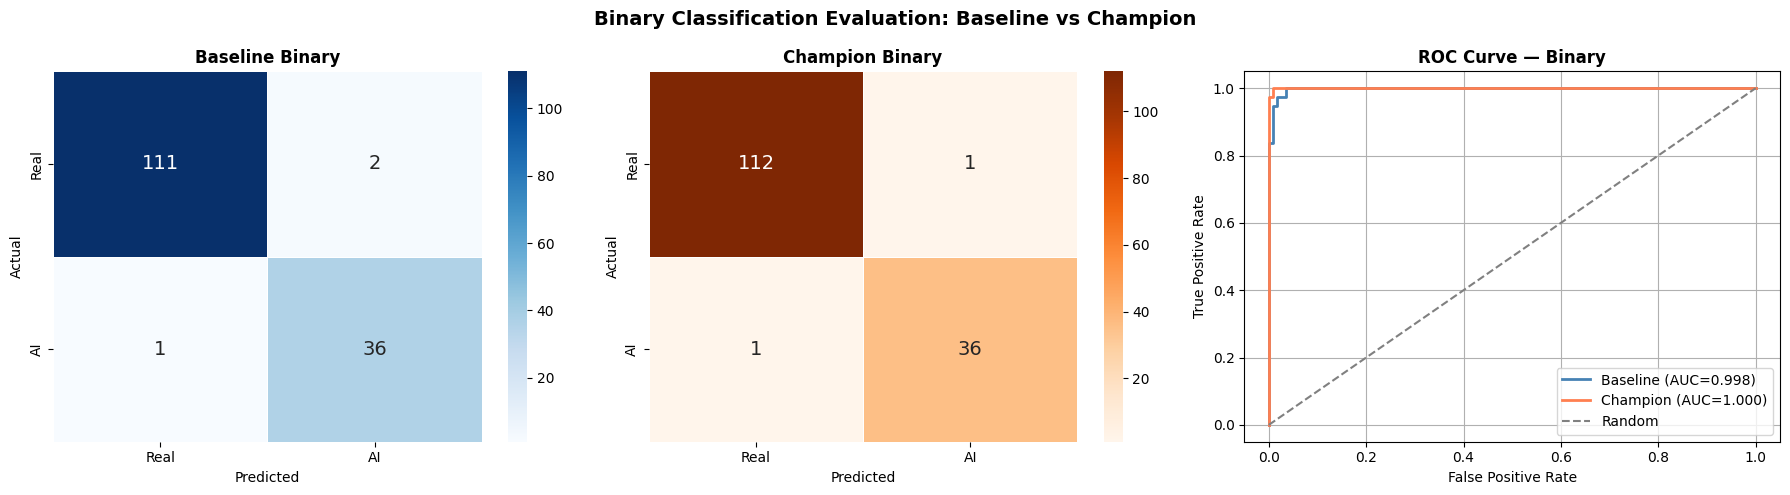

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax, preds, true, title, cmap in [
    (axes[0], base_bin_preds,  base_bin_true,  'Baseline Binary',  'Blues'),
    (axes[1], champ_bin_preds, champ_bin_true, 'Champion Binary',  'Oranges'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=BINARY_NAMES, yticklabels=BINARY_NAMES,
                linewidths=0.5, ax=ax, annot_kws={'size': 14})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ROC Curve
for probs, true, label, color in [
    (base_bin_probs,  base_bin_true,  'Baseline', 'steelblue'),
    (champ_bin_probs, champ_bin_true, 'Champion', 'coral'),
]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    axes[2].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)
axes[2].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — Binary', fontweight='bold')
axes[2].legend(); axes[2].grid(True)

plt.suptitle('Binary Classification Evaluation: Baseline vs Champion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_binary_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Category Classification Results

In [13]:
print('PROBLEM 2: CATEGORY CLASSIFICATION (5 classes)')

_, base_cat_acc, base_cat_preds, base_cat_probs, base_cat_true = evaluate(
    baseline_category, test_loader, criterion_category, DEVICE, 'category')
_, champ_cat_acc, champ_cat_preds, champ_cat_probs, champ_cat_true = evaluate(
    champion_category, test_loader, criterion_category, DEVICE, 'category')

print('\n BASELINE: Frozen ResNet-50 + Linear')
print(classification_report(base_cat_true, base_cat_preds,
      target_names=CATEGORY_NAMES, digits=4))
print(f'AUC-ROC (macro OvR): {roc_auc_score(base_cat_true, base_cat_probs, multi_class="ovr", average="macro"):.4f}')

print('\n CHAMPION: Fine-tuned ResNet-50 + Deep MLP')
print(classification_report(champ_cat_true, champ_cat_preds,
      target_names=CATEGORY_NAMES, digits=4))
print(f'AUC-ROC (macro OvR): {roc_auc_score(champ_cat_true, champ_cat_probs, multi_class="ovr", average="macro"):.4f}')

PROBLEM 2: CATEGORY CLASSIFICATION (5 classes)

 BASELINE: Frozen ResNet-50 + Linear
              precision    recall  f1-score   support

     animals     0.9375    1.0000    0.9677        30
        city     0.9677    1.0000    0.9836        30
        food     0.9677    1.0000    0.9836        30
      nature     1.0000    0.9032    0.9492        31
      people     1.0000    0.9655    0.9825        29

    accuracy                         0.9733       150
   macro avg     0.9746    0.9737    0.9733       150
weighted avg     0.9746    0.9733    0.9731       150

AUC-ROC (macro OvR): 0.9993

 CHAMPION: Fine-tuned ResNet-50 + Deep MLP
              precision    recall  f1-score   support

     animals     1.0000    0.9667    0.9831        30
        city     0.9355    0.9667    0.9508        30
        food     0.9667    0.9667    0.9667        30
      nature     0.9688    1.0000    0.9841        31
      people     1.0000    0.9655    0.9825        29

    accuracy                

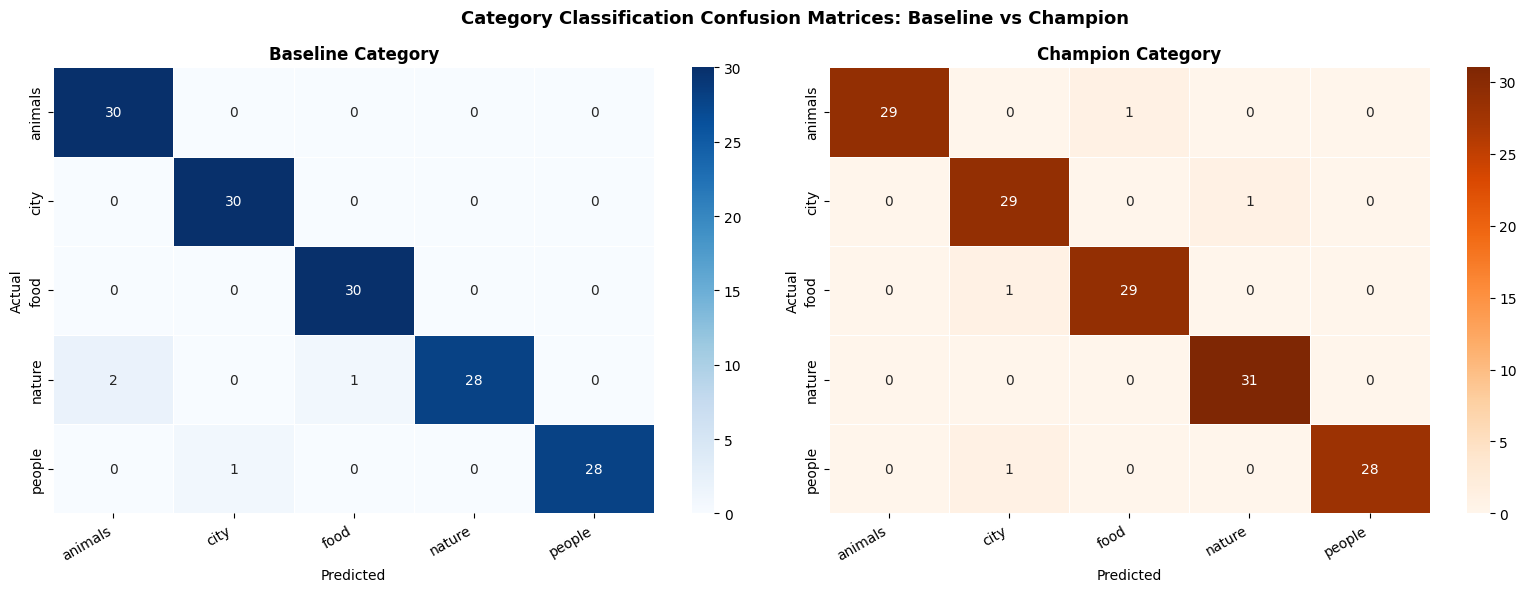

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, true, title, cmap in [
    (axes[0], base_cat_preds,  base_cat_true,  'Baseline Category', 'Blues'),
    (axes[1], champ_cat_preds, champ_cat_true, 'Champion Category', 'Oranges'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CATEGORY_NAMES, yticklabels=CATEGORY_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Category Classification Confusion Matrices: Baseline vs Champion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_category_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Head-to-Head Comparison Table

In [15]:
def safe_auc(true, probs, task='binary'):
    try:
        if task == 'binary':
            return roc_auc_score(true, probs)
        return roc_auc_score(true, probs, multi_class='ovr', average='macro')
    except: return float('nan')

results = pd.DataFrame({
    'Problem' : ['Binary','Binary','Category','Category'],
    'Model'   : ['Baseline','Champion','Baseline','Champion'],
    'Accuracy': [
        accuracy_score(base_bin_true,  base_bin_preds),
        accuracy_score(champ_bin_true, champ_bin_preds),
        accuracy_score(base_cat_true,  base_cat_preds),
        accuracy_score(champ_cat_true, champ_cat_preds),
    ],
    'F1 Macro': [
        f1_score(base_bin_true,  base_bin_preds,  average='macro'),
        f1_score(champ_bin_true, champ_bin_preds, average='macro'),
        f1_score(base_cat_true,  base_cat_preds,  average='macro'),
        f1_score(champ_cat_true, champ_cat_preds, average='macro'),
    ],
    'F1 Weighted': [
        f1_score(base_bin_true,  base_bin_preds,  average='weighted'),
        f1_score(champ_bin_true, champ_bin_preds, average='weighted'),
        f1_score(base_cat_true,  base_cat_preds,  average='weighted'),
        f1_score(champ_cat_true, champ_cat_preds, average='weighted'),
    ],
    'AUC-ROC' : [
        safe_auc(base_bin_true,  base_bin_probs,  'binary'),
        safe_auc(champ_bin_true, champ_bin_probs, 'binary'),
        safe_auc(base_cat_true,  base_cat_probs,  'category'),
        safe_auc(champ_cat_true, champ_cat_probs, 'category'),
    ],
})
results[['Accuracy','F1 Macro','F1 Weighted','AUC-ROC']] = \
    results[['Accuracy','F1 Macro','F1 Weighted','AUC-ROC']].round(4)

print('FINAL RESULTS SUMMARY — ResNet-50')
print(results.to_string(index=False))

results.to_csv("/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/resnet_results.csv", index=False)

FINAL RESULTS SUMMARY — ResNet-50
 Problem    Model  Accuracy  F1 Macro  F1 Weighted  AUC-ROC
  Binary Baseline    0.9800    0.9733       0.9801   0.9976
  Binary Champion    0.9867    0.9821       0.9867   0.9998
Category Baseline    0.9733    0.9733       0.9731   0.9993
Category Champion    0.9733    0.9734       0.9734   0.9994


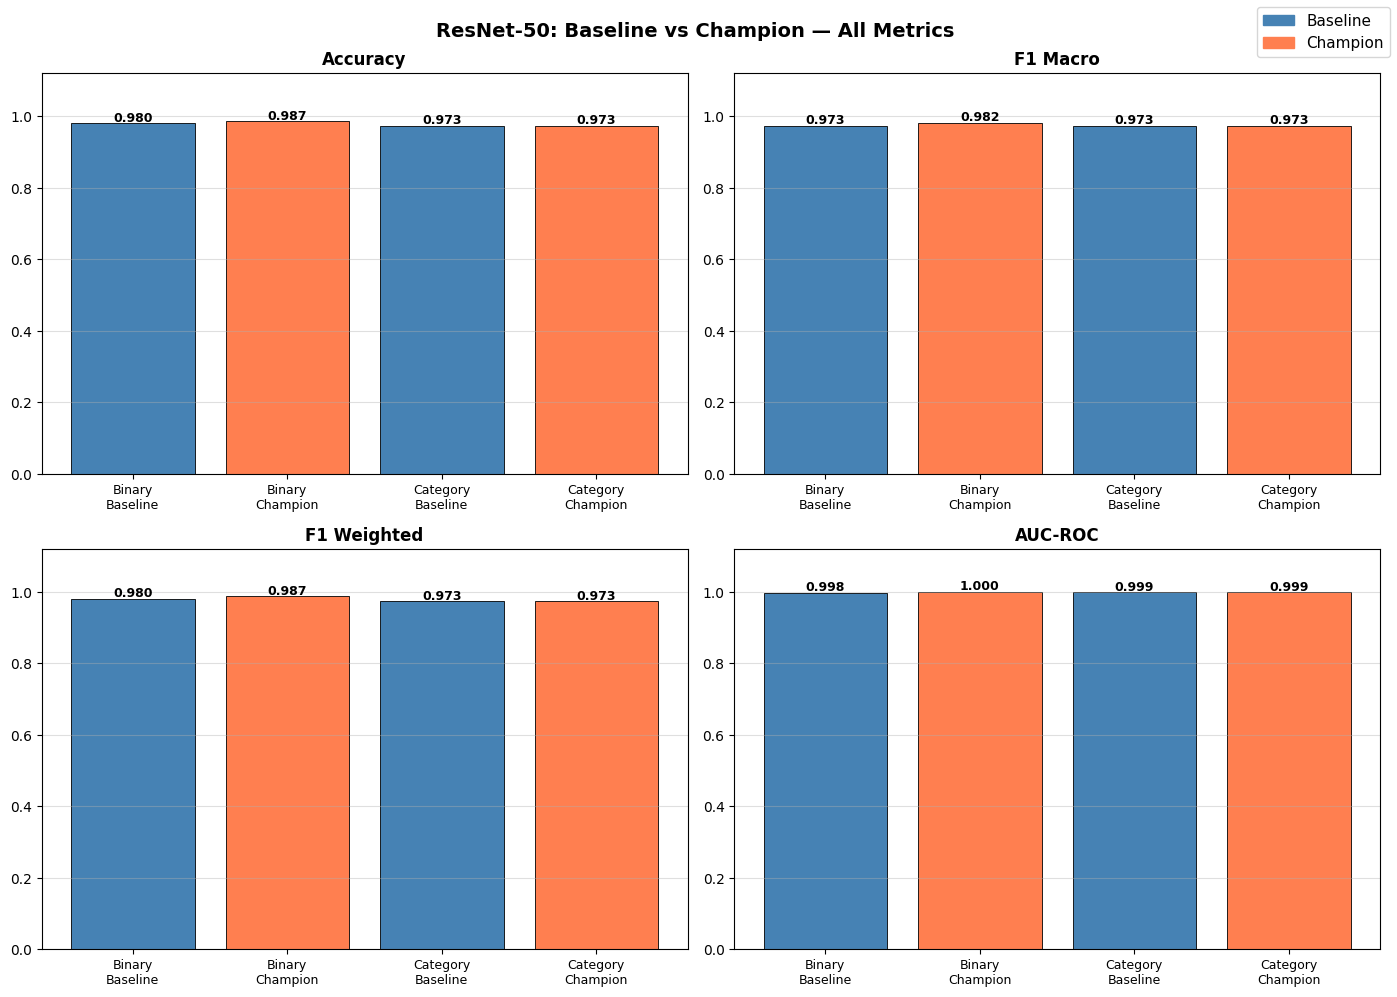

In [16]:
# Visual comparison bar chart
metrics = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'AUC-ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'Baseline': 'steelblue', 'Champion': 'coral'}

for ax, metric in zip(axes.flatten(), metrics):
    for problem in ['Binary', 'Category']:
        subset = results[results['Problem'] == problem]
        x_labels = [f'{problem}\n{m}' for m in subset['Model']]
        vals     = subset[metric].values
        bar_colors = [colors[m] for m in subset['Model']]
        bars = ax.bar(x_labels, vals, color=bar_colors, edgecolor='black', linewidth=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.12); ax.grid(axis='y', alpha=0.4)
    ax.tick_params(axis='x', labelsize=9)

handles = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
fig.legend(handles=handles, loc='upper right', fontsize=11)
plt.suptitle('ResNet-50: Baseline vs Champion — All Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Error Analysis — What is the model getting wrong?

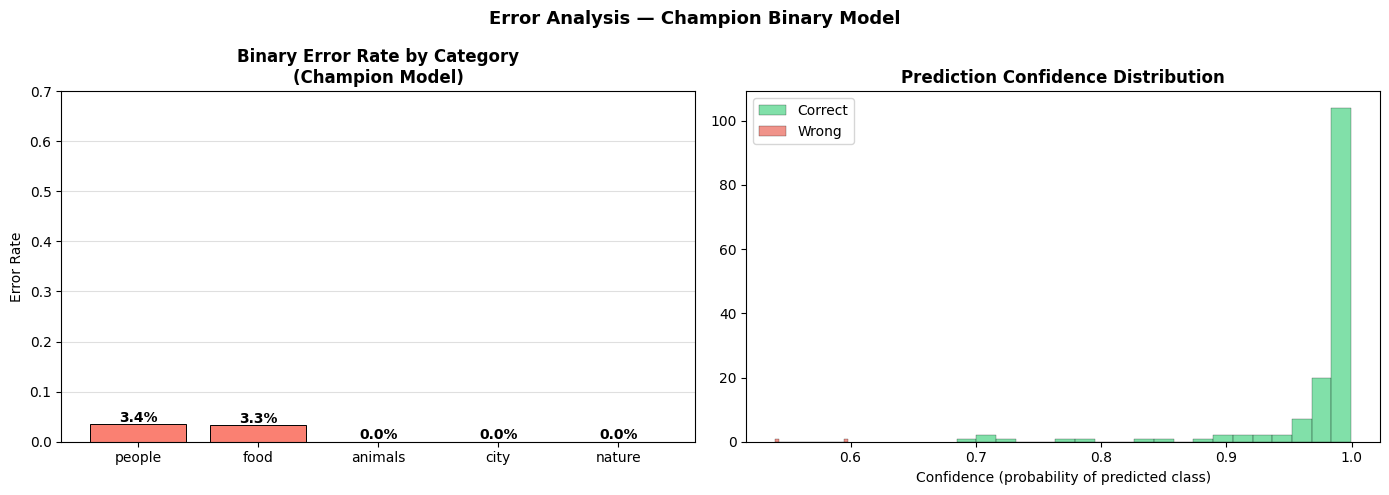

          total  correct  error_rate
category                            
people       29       28    0.034483
food         30       29    0.033333
animals      30       30    0.000000
city         30       30    0.000000
nature       31       31    0.000000


In [17]:
# Collect per-image predictions from champion binary model
@torch.no_grad()
def get_predictions_with_metadata(model, dataset, device, task='binary'):
    model.eval()
    rows = []
    for idx in range(len(dataset)):
        img_t, b_label, c_label = dataset[idx]
        out   = model(img_t.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
        pred  = out.argmax(dim=1).item()
        true  = b_label.item() if task == 'binary' else c_label.item()
        rows.append({
            'path'    : dataset.df.iloc[idx]['path'],
            'category': dataset.df.iloc[idx]['category'],
            'true'    : true,
            'pred'    : pred,
            'correct' : pred == true,
            'confidence': probs[pred].item(),
        })
    return pd.DataFrame(rows)

print('Collecting champion binary predictions...')
df_preds = get_predictions_with_metadata(champion_binary, test_ds, DEVICE, 'binary')

# Error rate by category
error_by_cat = df_preds.groupby('category').agg(
    total=('correct','count'),
    correct=('correct','sum')
)
error_by_cat['error_rate'] = 1 - error_by_cat['correct'] / error_by_cat['total']
error_by_cat = error_by_cat.sort_values('error_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error rate bar
bars = axes[0].bar(error_by_cat.index, error_by_cat['error_rate'],
                   color='salmon', edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, error_by_cat['error_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.1%}', ha='center', fontweight='bold')
axes[0].set_title('Binary Error Rate by Category\n(Champion Model)', fontweight='bold')
axes[0].set_ylabel('Error Rate'); axes[0].set_ylim(0, 0.7)
axes[0].grid(axis='y', alpha=0.4)

# Confidence distribution: correct vs wrong
correct_conf = df_preds[df_preds['correct']]['confidence']
wrong_conf   = df_preds[~df_preds['correct']]['confidence']
axes[1].hist(correct_conf, bins=20, alpha=0.6, color='#2ECC71', label='Correct', edgecolor='black', linewidth=0.3)
axes[1].hist(wrong_conf,   bins=20, alpha=0.6, color='#E74C3C', label='Wrong',   edgecolor='black', linewidth=0.3)
axes[1].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[1].set_xlabel('Confidence (probability of predicted class)')
axes[1].legend()

plt.suptitle('Error Analysis — Champion Binary Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_error_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(error_by_cat[['total','correct','error_rate']].to_string())

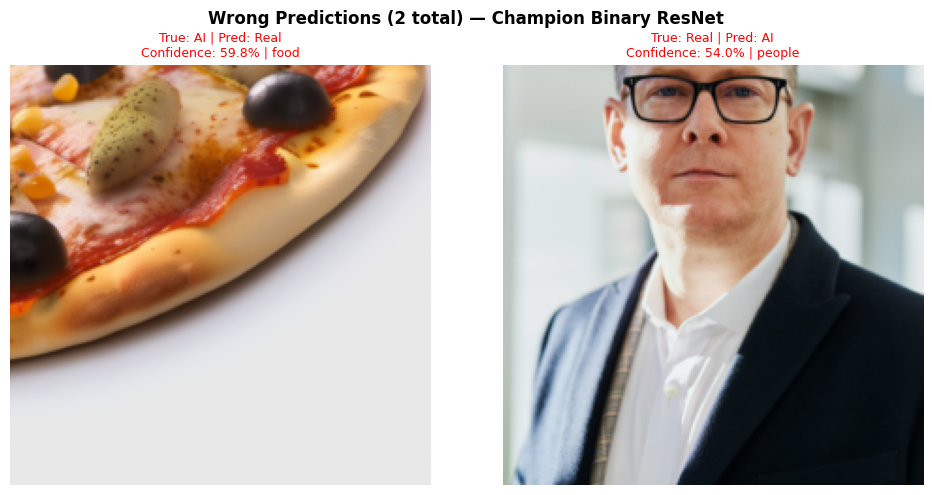


Total wrong: 2 / 150 (1.3% error rate)


In [20]:
# Show most confidently wrong predictions
def unnormalize(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t * std + mean).clamp(0,1)

wrong = df_preds[~df_preds['correct']].sort_values('confidence', ascending=False)
n_wrong = len(wrong)

if n_wrong == 0:
    print(' No wrong predictions on the test set!')
else:
    # Dynamically size grid based on actual number of wrong predictions
    n_cols = min(4, n_wrong)
    n_rows = (n_wrong + n_cols - 1) // n_cols   # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = np.array(axes).flatten()  # always a flat list

    for ax, (_, row) in zip(axes, wrong.iterrows()):
        img_t, _, _ = test_ds[row.name]
        img = unnormalize(img_t).permute(1,2,0).numpy()
        ax.imshow(img)
        true_name = IDX_TO_BINARY[row['true']]
        pred_name = IDX_TO_BINARY[row['pred']]
        ax.set_title(
            f'True: {true_name} | Pred: {pred_name}\n'
            f'Confidence: {row["confidence"]:.1%} | {row["category"]}',
            fontsize=9, color='red'
        )
        ax.axis('off')

    # Hide any unused axes
    for ax in axes[n_wrong:]:
        ax.axis('off')

    plt.suptitle(f'Wrong Predictions ({n_wrong} total) — Champion Binary ResNet',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('resnet_wrong_predictions.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'\nTotal wrong: {n_wrong} / {len(df_preds)} ({n_wrong/len(df_preds)*100:.1f}% error rate)')

## 12. Save Models

In [19]:
torch.save(baseline_binary.state_dict(),   "/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/resnet_baseline_binary.pth")
torch.save(baseline_category.state_dict(), "/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/resnet_baseline_category.pth")
torch.save(champion_binary.state_dict(),   "/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/resnet_champion_binary.pth")
torch.save(champion_category.state_dict(), "/Users/bestek/PycharmProjects/Computer-Vision-Project/Beste/resnet_champion_category.pth")

print('RESNET NOTEBOOK COMPLETE')
print('''
Summary:
  Problem 1 — Binary (AI vs Real)
    Baseline : Frozen ResNet-50 + Linear(2048→2)
    Champion : Fine-tuned ResNet-50 + MLP(2048→512→256→2)

  Problem 2 — Category (5 classes)
    Baseline : Frozen ResNet-50 + Linear(2048→5)
    Champion : Fine-tuned ResNet-50 + MLP(2048→512→256→5)

  Imbalance : WeightedRandomSampler (binary task)
  Optimizer : Adam with weight_decay=1e-4 (champion)
  Scheduler : ReduceLROnPlateau (champion)
''')

RESNET NOTEBOOK COMPLETE

Summary:
  Problem 1 — Binary (AI vs Real)
    Baseline : Frozen ResNet-50 + Linear(2048→2)
    Champion : Fine-tuned ResNet-50 + MLP(2048→512→256→2)

  Problem 2 — Category (5 classes)
    Baseline : Frozen ResNet-50 + Linear(2048→5)
    Champion : Fine-tuned ResNet-50 + MLP(2048→512→256→5)

  Imbalance : WeightedRandomSampler (binary task)
  Optimizer : Adam with weight_decay=1e-4 (champion)
  Scheduler : ReduceLROnPlateau (champion)

